In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
model = joblib.load("../resources/rf_model.joblib")

a549 = pd.read_csv('../../../task2_preprocessed/preprocessed_a549.csv')
hct = pd.read_csv('../../../task2_preprocessed/preprocessed_hct.csv')
hep2 = pd.read_csv('../../../task2_preprocessed/preprocessed_hep2.csv')
k562 = pd.read_csv('../../../task2_preprocessed/preprocessed_k562.csv')
mc67 = pd.read_csv('../../../task2_preprocessed/preprocessed_mc67.csv')  

cell_lines = {
    "A549": a549,
    "HCT": hct,
    "HEP2": hep2,
    "K562": k562,
    "MC67": mc67
}

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

columns_to_drop = ['transcript_id', 'transcript_position', 'label']

X_test = pd.read_csv('../../../f5_data/f5_test.csv').drop(columns=columns_to_drop)
y_test = pd.read_csv('../../../f5_data/f5_test.csv')['label']
y_prob = model.predict_proba(X_test)[:, 1] 


In [23]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")


ROC-AUC: 0.9113
PR-AUC: 0.3501


In [24]:
import numpy as np

# Avoid division by zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold = {best_threshold:.3f}")
print(f"Best F1 score = {f1_scores[best_idx]:.3f}")


Best threshold = 0.220
Best F1 score = 0.423


In [29]:
results = {}

for name, df in cell_lines.items():
    X = df.drop(columns=['transcript_id', 'transcript_position'], errors='ignore') 
    probs = model.predict_proba(X)[:, 1] 
    df['pred_prob'] = probs
    df['pred_label'] = (probs >= 0.220).astype(int)
    results[name] = df
    print(f"{name}: {df['pred_label'].sum()} predicted modified sites out of {len(df)}")


A549: 1278 predicted modified sites out of 100000
HCT: 1653 predicted modified sites out of 100000
HEP2: 1579 predicted modified sites out of 100000
K562: 1410 predicted modified sites out of 100000
MC67: 1412 predicted modified sites out of 100000


In [48]:
df.head()

,transcript_id,transcript_position,log_mean_0,log_mean_1,log_mean_2,log_std_0,log_std_1,log_std_2,dwell_0,dwell_1,...,log_std_2_iqr,dwell_0_iqr,log_dwell_1_iqr,log_dwell_2_iqr,pred_prob,pred_label,pos_rank,max_rank,relative_pos,site
0,ENST00000418539,108,-5.707790,-4.919881,-5.370888,1.453486,1.291984,1.673726,124.4,129.8,...,-20.723266,0.0,-20.723266,-20.723266,0.06,0,1.0,2.0,0.5,ENST00000418539:108
1,ENST00000418539,139,-4.832071,-5.177871,-5.202488,1.136229,1.590867,0.537662,106.3,99.2,...,-20.723266,0.0,-20.723266,-20.723266,0.05,0,2.0,2.0,1.0,ENST00000418539:139
2,ENST00000383898,75,-4.483838,-4.979258,-4.427024,1.700192,2.438565,1.228470,90.2,117.6,...,-20.723266,0.0,-20.723266,-20.723266,0.05,0,1.0,1.0,1.0,ENST00000383898:75
3,ENST00000610460,78,-4.003042,-4.963007,-5.021201,1.713798,1.647378,1.191866,115.6,120.9,...,-20.723266,0.0,-20.723266,-20.723266,0.10,0,1.0,1.0,1.0,ENST00000610460:78
4,ENST00000619779,78,-4.727993,-5.812482,-4.427024,1.576820,1.316676,0.962793,117.2,121.6,...,-20.723266,0.0,-20.723266,-20.723266,0.10,0,1.0,1.0,1.0,ENST00000619779:78


  Cell Line  Mean Prob  % Modified
0      A549   0.060387       1.278
1       HCT   0.060099       1.653
2      HEP2   0.058534       1.579
3      K562   0.060193       1.410
4      MC67   0.060662       1.412


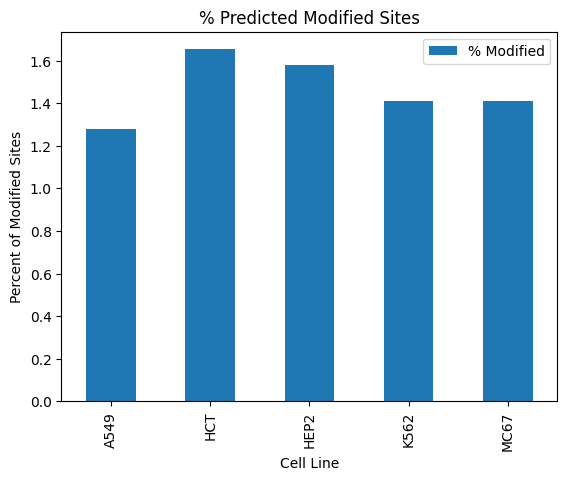

In [30]:
import matplotlib.pyplot as plt

summary = []
for name, df in results.items():
    mean_prob = df['pred_prob'].mean()
    modified_pct = df['pred_label'].mean() * 100
    summary.append((name, mean_prob, modified_pct))

summary_df = pd.DataFrame(summary, columns=['Cell Line', 'Mean Prob', '% Modified'])
print(summary_df)

# Visualise
summary_df.plot(x='Cell Line', y='% Modified', kind='bar', title='% Predicted Modified Sites')
plt.ylabel('Percent of Modified Sites')
plt.show()


## Metagene Plot

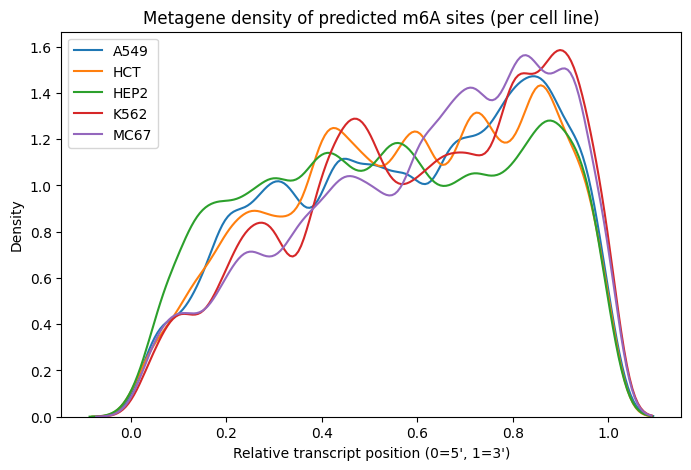

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def compute_relative(df):
    if 'transcript_length' in df.columns:
        df['relative_pos'] = df['transcript_position'] / df['transcript_length']
    else:
        # approximate using rank within transcript
        df['pos_rank'] = df.groupby('transcript_id')['transcript_position'].rank(method='max')
        df['max_rank'] = df.groupby('transcript_id')['pos_rank'].transform('max')
        df['relative_pos'] = df['pos_rank'] / df['max_rank']
    return df

plt.figure(figsize=(8,5))
for cell, df in results.items():
    df2 = compute_relative(df)
    # kernel density of predicted modified sites only
    sns.kdeplot(df2.loc[df2['pred_label']==1,'relative_pos'], label=cell, bw_adjust=0.5)
plt.xlabel("Relative transcript position (0=5', 1=3')")
plt.title("Metagene density of predicted m6A sites (per cell line)")
plt.legend()
plt.show()


*to be edited: (graph changed after adjusting threshold)
Conclusion: Predicted m⁶A sites are strongly enriched toward the 3′ UTR.

Comparison between cell lines:
A549 and K562 has a sharper, high density peak closer to the 3' end.
HCT shows broader distributions, with a secondary peak in the coding sequence region (~ 0.4).
HEP2 has a broader distribution, with lower density levels where MC67 has a peak slightly further from the 3' end.

Although all cell lines show 3′-UTR enrichment, there are subtle differences in distribution shapes.

## Difference between significant features 

In [32]:
df.head()
X = df.drop(columns=['transcript_id', 'transcript_position', 'pred_prob', 'pred_label', 'pos_rank', 'max_rank', 'relative_pos'])

In [ ]:
# Extract feature importances
importances = model.feature_importances_

features = X.columns 

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top5 = importance_df.head(5)
print(top5)


      feature  importance
77  all_dwell    0.072364
76    all_std    0.066036
7     dwell_1    0.065098
4   log_std_1    0.059548
6     dwell_0    0.053301


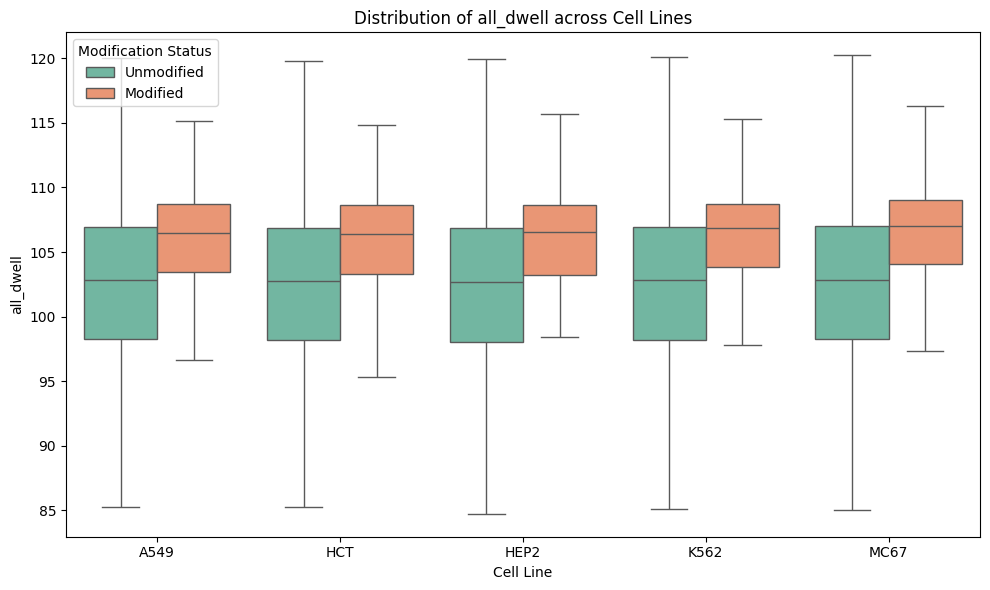

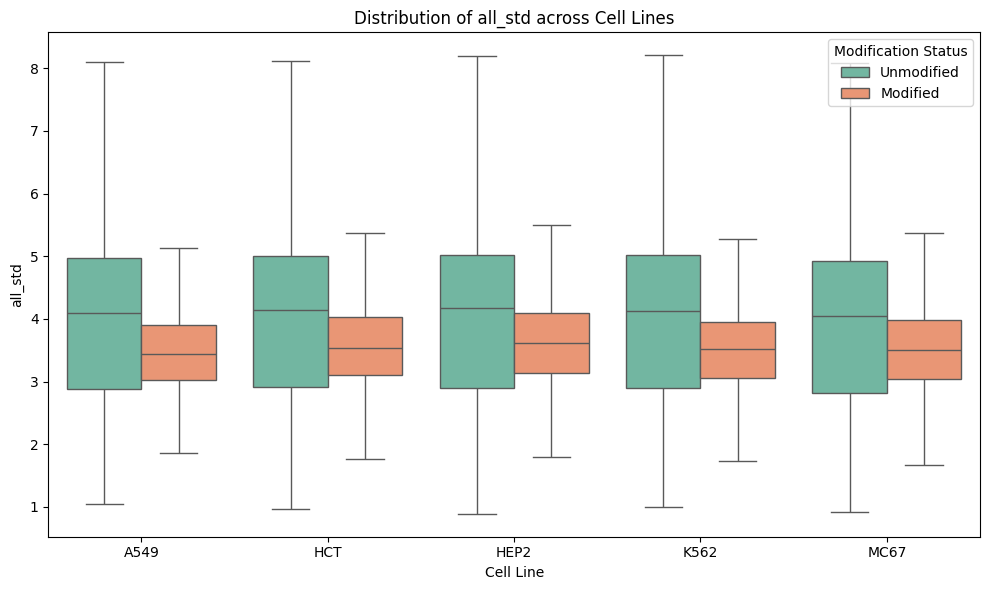

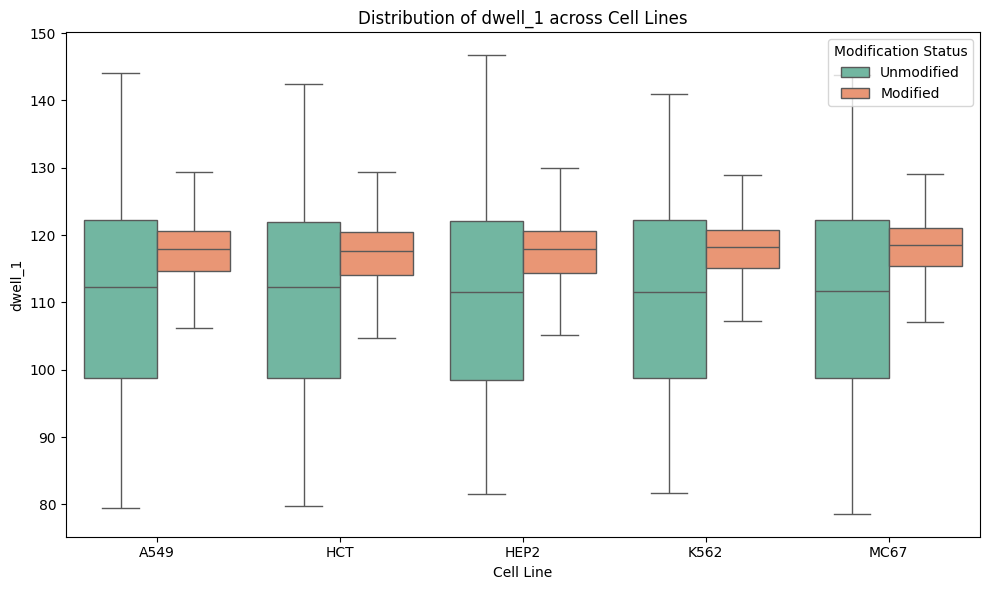

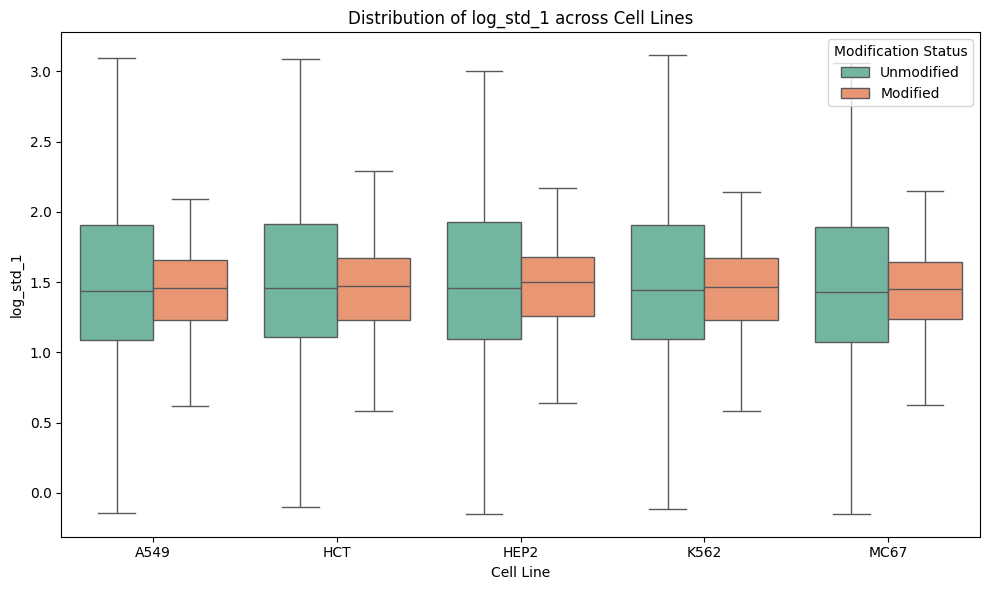

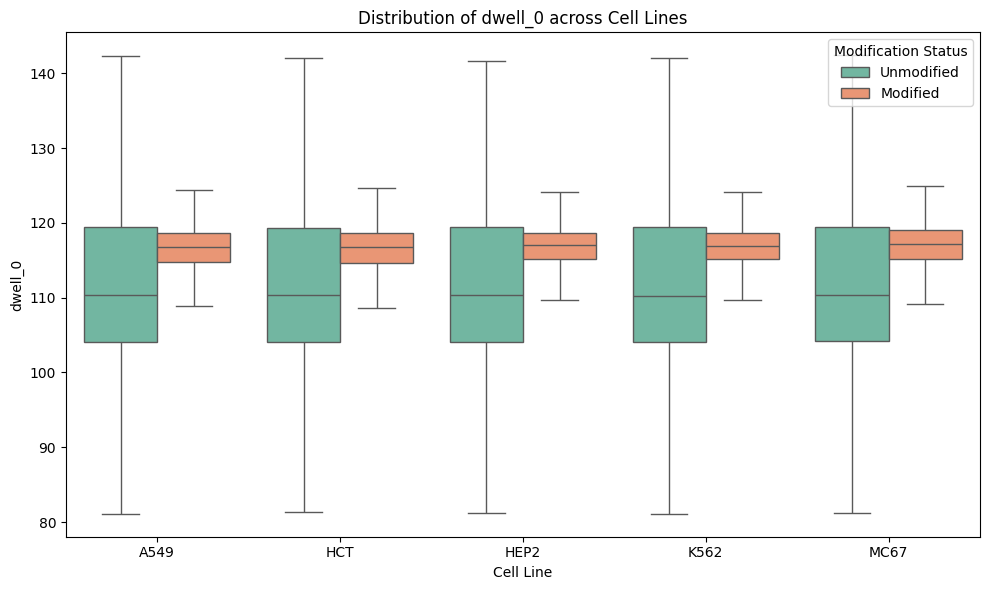

In [ ]:
sig_features = ['all_dwell', 'all_std', 'dwell_1', 'log_std_1', 'dwell_0'] 

for feat in sig_features:
    plt.figure(figsize=(10,6))
    combined_data = []

    for cell, df in results.items():
        temp = df[['pred_label', feat]].copy()
        temp['cell_line'] = cell
        temp['status'] = temp['pred_label'].map({1: 'Modified', 0: 'Unmodified'})
        combined_data.append(temp)

    plot_df = pd.concat(combined_data, ignore_index=True)

    sns.boxplot(
        data=plot_df,
        x='cell_line',
        y=feat,
        hue='status',
        showfliers=False, 
        palette='Set2'
    )

    plt.title(f"Distribution of {feat} across Cell Lines")
    plt.xlabel("Cell Line")
    plt.ylabel(feat)
    plt.legend(title='Modification Status')
    plt.tight_layout()
    plt.show()


Across all cell lines, it is observed that features related to dwell time (e.g., all_dwell, dwell_1, dwell_0) are generally higher for modified sites, while signal variation features (e.g., all_std) tend to be lower in modified regions. This suggests that m⁶A slows down RNA in the nanopore and produces more stable signals, consistent with known effects of methylation on RNA structure.

Furthermore, the patterns were consistent across all five cell lines, suggesting that the biophysical effects of m⁶A on nanopore signal characteristics are conserved despite differences in cell type or transcript composition.

## Overlap across cell lines

In [44]:
def site_set(df, threshold=0.220):
    df['site'] = df['transcript_id'].astype(str) + ":" + df['transcript_position'].astype(str)
    return set(df.loc[df['pred_prob']>=threshold, 'site'])

sets = {cell: site_set(df) for cell, df in results.items()}

# create a pairwise overlap matrix
cells = list(sets.keys())
import numpy as np
overlap = pd.DataFrame(index=cells, columns=cells, data=0)
for i in cells:
    for j in cells:
        a, b = sets[i], sets[j]
        overlap.loc[i,j] = len(a & b)
print(overlap)


      A549   HCT  HEP2  K562  MC67
A549  1278   379   237   349     0
HCT    379  1653   420   440     0
HEP2   237   420  1579   347     0
K562   349   440   347  1410     0
MC67     0     0     0     0  1412


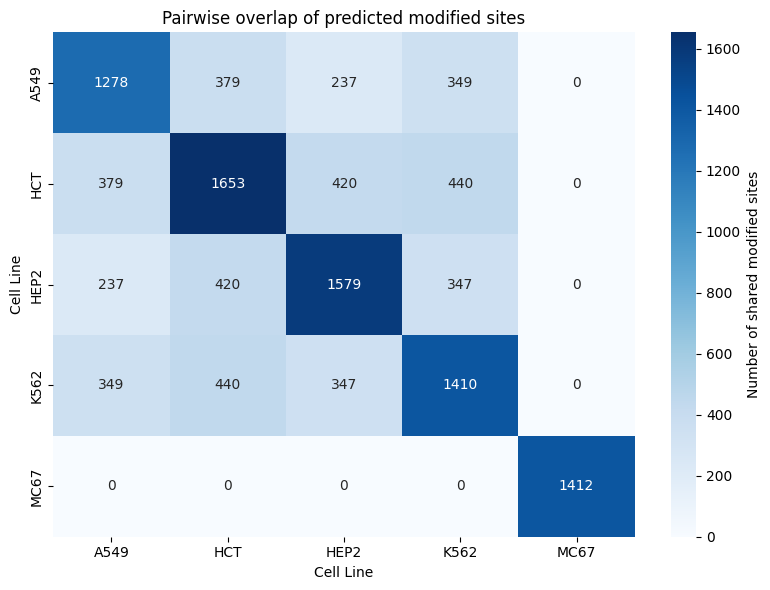

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    overlap.astype(int),          
    annot=True,                 
    fmt="d",
    cmap="Blues",                
    cbar_kws={'label': 'Number of shared modified sites'}
)

plt.title("Pairwise overlap of predicted modified sites")
plt.xlabel("Cell Line")
plt.ylabel("Cell Line")
plt.tight_layout()
plt.show()


The diagonal values represent the total predicted modified sites per cell line. For example, A549 has 1,278 predicted modified sites.

The off-diagonal values indicate the number of shared sites between cell lines. For instance, A549 and HCT share 379 sites. Overall, the heatmap shows that some sites are shared across cell lines, suggesting a subset of conserved modifications. However, none of MC67’s sites overlap with the other four cell lines.

These patterns suggest cell-type-specific regulation of m⁶A, with certain sites conserved among related lineages. Most m⁶A sites are unique to each cell line, while a subset is shared between HCT, HEP2, and K562. MC67, in contrast, exhibits entirely unique modifications, highlighting both conserved and cell-line-specific methylation patterns.